# 05 — Graph Classification and Link Prediction

The previous notebooks focused mainly on **node classification**.

This notebook expands graph learning to two additional prediction levels:

1. **Graph classification** — one prediction for an entire graph
2. **Link prediction** — predict whether an edge should exist between two nodes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

# Part A — Graph Classification

## 1. From node embeddings to a graph embedding

A GNN first creates a representation for each node.

To classify an entire graph, node representations must be pooled:

$$
h_G
=
\operatorname{POOL}
\left(
\left\{
h_v:v\in G
\right\}
\right)
$$

Common pooling functions are:

$$
\operatorname{MEAN},\qquad
\operatorname{SUM},\qquad
\operatorname{MAX}
$$

The pooled vector $h_G$ is then passed to a graph-level classifier.

## 2. Manual pooling example

Suppose the final node embeddings are:

$$
H=
\begin{bmatrix}
1 & 2\\
3 & 4\\
5 & 6
\end{bmatrix}
$$

Mean pooling produces:

$$
h_G=
\begin{bmatrix}
3 & 4
\end{bmatrix}
$$

In [2]:
H = np.array([[1.0,2.0],[3.0,4.0],[5.0,6.0]])

mean_pool = H.mean(axis=0)
sum_pool = H.sum(axis=0)
max_pool = H.max(axis=0)

print("Mean pooling:",mean_pool)
print("Sum pooling:",sum_pool)
print("Max pooling:",max_pool)

Mean pooling: [3. 4.]
Sum pooling: [ 9. 12.]
Max pooling: [5. 6.]


## 3. Load MUTAG

MUTAG contains small molecular graphs.

Each sample is a separate graph with:

- node features,
- graph edges,
- one graph-level class label.

In [3]:
# Uncomment in Google Colab if needed:
!pip -q install torch-geometric

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv,global_mean_pool

dataset = TUDataset(root="data/TUDataset",name="MUTAG")
dataset = dataset.shuffle()

print("Number of graphs:",len(dataset))
print("Node features:",dataset.num_node_features)
print("Classes:",dataset.num_classes)
print()
print("First graph:")
print(dataset[0])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00


Number of graphs: 188
Node features: 7
Classes: 2

First graph:
Data(edge_index=[2, 44], x=[21, 7], edge_attr=[44, 4], y=[1])


Processing...
Done!


## 4. Graph-level train, validation, and test split

The split is performed across graphs rather than across nodes.

In [4]:
n = len(dataset)
n_train = int(0.7*n)
n_val = int(0.15*n)

train_dataset = dataset[:n_train]
val_dataset = dataset[n_train:n_train+n_val]
test_dataset = dataset[n_train+n_val:]

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=64)
test_loader = DataLoader(test_dataset,batch_size=64)

print("Train graphs:",len(train_dataset))
print("Validation graphs:",len(val_dataset))
print("Test graphs:",len(test_dataset))

Train graphs: 131
Validation graphs: 28
Test graphs: 29


## 5. GCN graph classifier

The computation is:

**node features** → **GCN layers** → **global mean pooling** → **graph classifier**

In [5]:
class GCNGraphClassifier(nn.Module):
    def __init__(self,in_dim,hidden_dim,out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim,hidden_dim)
        self.conv2 = GCNConv(hidden_dim,hidden_dim)
        self.fc = nn.Linear(hidden_dim,out_dim)

    def forward(self,x,edge_index,batch):
        x = F.relu(self.conv1(x,edge_index))
        x = F.relu(self.conv2(x,edge_index))
        graph_embedding = global_mean_pool(x,batch)
        return self.fc(graph_embedding)

graph_model = GCNGraphClassifier(dataset.num_node_features,64,dataset.num_classes)

## 6. Train the graph classifier

In [6]:
def graph_accuracy(model,loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            logits = model(batch.x,batch.edge_index,batch.batch)
            pred = logits.argmax(dim=1)
            correct += int((pred == batch.y).sum())
            total += batch.num_graphs

    return correct/total

optimizer = torch.optim.Adam(graph_model.parameters(),lr=0.01,weight_decay=5e-4)
history = {"loss":[],"train_acc":[],"val_acc":[]}

for epoch in range(150):
    graph_model.train()
    total_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()
        logits = graph_model(batch.x,batch.edge_index,batch.batch)
        loss = F.cross_entropy(logits,batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*batch.num_graphs

    history["loss"].append(total_loss/len(train_dataset))
    history["train_acc"].append(graph_accuracy(graph_model,train_loader))
    history["val_acc"].append(graph_accuracy(graph_model,val_loader))

## 7. Graph-classification learning curves

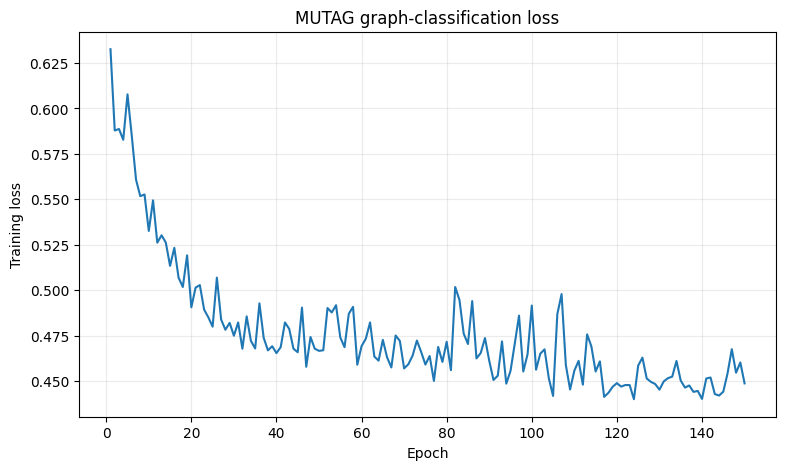

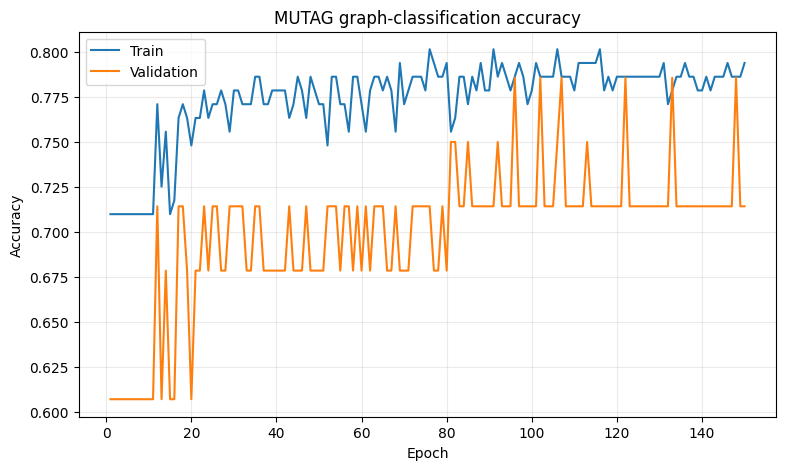

In [7]:
epochs = np.arange(1,len(history["loss"])+1)

plt.figure(figsize=(9,5))
plt.plot(epochs,history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("MUTAG graph-classification loss")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(epochs,history["train_acc"],label="Train")
plt.plot(epochs,history["val_acc"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MUTAG graph-classification accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [8]:
test_accuracy = graph_accuracy(graph_model,test_loader)
print("Graph-classification test accuracy:",test_accuracy)

Graph-classification test accuracy: 0.6551724137931034


# Part B — Link Prediction

## 8. Link-prediction objective

Link prediction asks:

> Given nodes $i$ and $j$, should an edge connect them?

A GNN first produces node embeddings:

$$
z_i=\operatorname{GNN}(x_i)
$$

A simple dot-product decoder uses:

$$
s_{ij}=z_i^Tz_j
$$

and:

$$
P((i,j)\in E)
=
\sigma(z_i^Tz_j)
$$

## 9. Positive and negative edges

Training needs both:

- **positive edges** — observed graph edges,
- **negative edges** — sampled node pairs treated as non-edges.

Negative sampling is necessary because sparse graphs contain many more possible non-edges than observed edges.

In [9]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score,average_precision_score

## 10. Prepare Cora for link prediction

`RandomLinkSplit` creates separate training, validation, and test edge sets.

This keeps message-passing edges separate from the edge labels used for evaluation.

In [10]:
cora = Planetoid(root="data/Planetoid",name="Cora")[0]

transform = RandomLinkSplit(num_val=0.05,num_test=0.1,is_undirected=True,add_negative_train_samples=True)
train_data,val_data,test_data = transform(cora)

print("Training message-passing edges:",train_data.edge_index.shape[1])
print("Training labeled edges:",train_data.edge_label_index.shape[1])
print("Validation labeled edges:",val_data.edge_label_index.shape[1])
print("Test labeled edges:",test_data.edge_label_index.shape[1])

Processing...


Training message-passing edges: 8976
Training labeled edges: 8976
Validation labeled edges: 526
Test labeled edges: 1054


Done!


## 11. GraphSAGE encoder and dot-product decoder

In [11]:
class LinkEncoder(nn.Module):
    def __init__(self,in_dim,hidden_dim,embedding_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim,hidden_dim)
        self.conv2 = SAGEConv(hidden_dim,embedding_dim)

    def forward(self,x,edge_index):
        x = F.relu(self.conv1(x,edge_index))
        return self.conv2(x,edge_index)

def decode(z,edge_label_index):
    src = z[edge_label_index[0]]
    dst = z[edge_label_index[1]]
    return (src*dst).sum(dim=1)

link_model = LinkEncoder(cora.num_node_features,64,32)

## 12. ROC-AUC and Average Precision

ROC-AUC measures how well the model ranks positive edges above negative edges.

Average Precision summarizes precision-recall performance and is useful for link-prediction evaluation.

In [12]:
def evaluate_links(model,split_data):
    model.eval()

    with torch.no_grad():
        z = model(split_data.x,split_data.edge_index)
        logits = decode(z,split_data.edge_label_index)
        probs = torch.sigmoid(logits).cpu().numpy()
        labels = split_data.edge_label.cpu().numpy()

    auc = roc_auc_score(labels,probs)
    ap = average_precision_score(labels,probs)

    return auc,ap,probs,labels

## 13. Train the link predictor

In [13]:
optimizer = torch.optim.Adam(link_model.parameters(),lr=0.01,weight_decay=1e-4)
link_history = {"loss":[],"val_auc":[],"val_ap":[]}

for epoch in range(150):
    link_model.train()
    optimizer.zero_grad()

    z = link_model(train_data.x,train_data.edge_index)
    logits = decode(z,train_data.edge_label_index)
    loss = F.binary_cross_entropy_with_logits(logits,train_data.edge_label.float())

    loss.backward()
    optimizer.step()

    val_auc,val_ap,_,_ = evaluate_links(link_model,val_data)

    link_history["loss"].append(loss.item())
    link_history["val_auc"].append(val_auc)
    link_history["val_ap"].append(val_ap)

## 14. Link-prediction learning curves

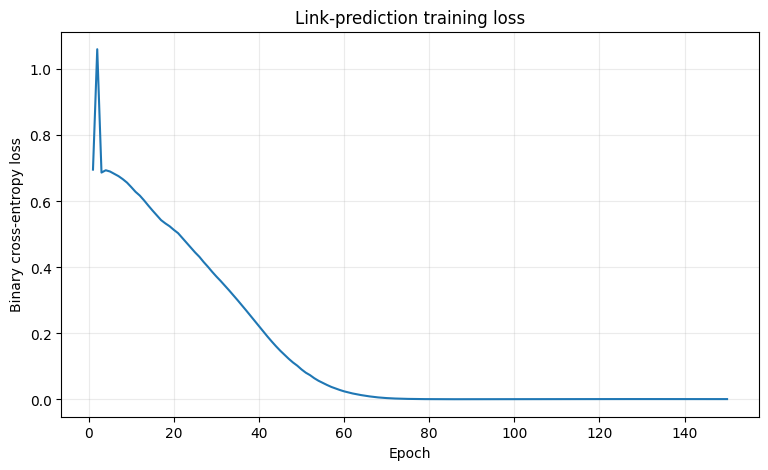

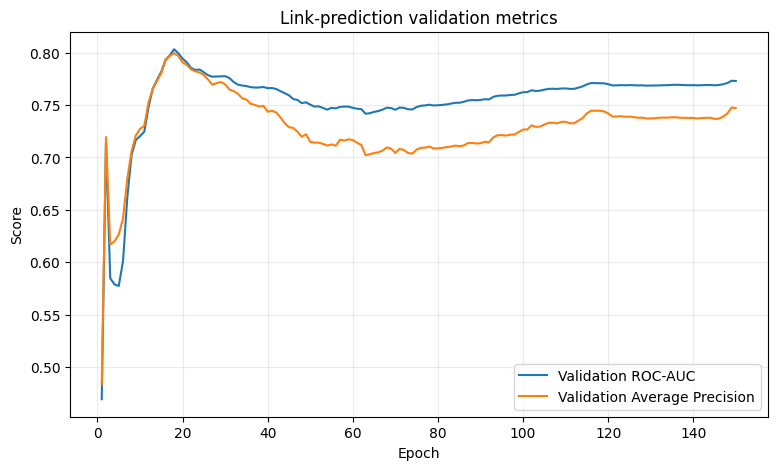

In [14]:
epochs = np.arange(1,len(link_history["loss"])+1)

plt.figure(figsize=(9,5))
plt.plot(epochs,link_history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Link-prediction training loss")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(epochs,link_history["val_auc"],label="Validation ROC-AUC")
plt.plot(epochs,link_history["val_ap"],label="Validation Average Precision")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Link-prediction validation metrics")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 15. Test evaluation

In [15]:
test_auc,test_ap,test_probs,test_labels = evaluate_links(link_model,test_data)

print("Test ROC-AUC:",test_auc)
print("Test Average Precision:",test_ap)

Test ROC-AUC: 0.7488811035217784
Test Average Precision: 0.7095675011806816


## 16. Positive vs negative link-score distributions

This plot is included because it directly shows whether the trained model assigns higher probabilities to observed edges than to sampled non-edges.

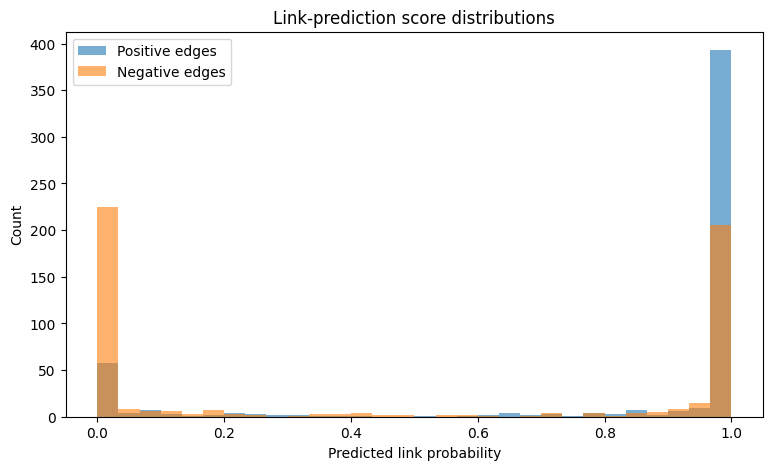

In [16]:
positive_scores = test_probs[test_labels == 1]
negative_scores = test_probs[test_labels == 0]

plt.figure(figsize=(9,5))
plt.hist(positive_scores,bins=30,alpha=0.6,label="Positive edges")
plt.hist(negative_scores,bins=30,alpha=0.6,label="Negative edges")
plt.xlabel("Predicted link probability")
plt.ylabel("Count")
plt.title("Link-prediction score distributions")
plt.legend()
plt.show()

## 17. Prediction levels across the GNN folder

| Task | Model output | Example target |
|---|---|---|
| Node classification | One prediction per node | Paper category |
| Link prediction | One prediction per candidate edge | Edge exists / does not exist |
| Graph classification | One prediction per graph | Molecular class |

The same message-passing machinery can support different prediction levels by changing the final readout and loss.

## 18. Final architecture comparison

| Architecture | Aggregation idea | Main strength |
|---|---|---|
| GCN | Degree-normalized neighborhood mixing | Simple and efficient graph convolution |
| GraphSAGE | Learned neighborhood aggregation | Inductive reuse and sampling |
| GAT | Learned attention over neighbors | Adaptive neighbor importance |

The common principle is:

> Learn representations by repeatedly exchanging and transforming information over graph edges.

## 19. Key takeaways

1. Graph pooling converts variable-size node sets into fixed-size graph representations.
2. Graph classification predicts one output for an entire graph.
3. Link prediction scores candidate node pairs using learned node embeddings.
4. Negative sampling provides non-edge examples.
5. ROC-AUC and Average Precision are useful link-prediction metrics.
6. Node-, edge-, and graph-level tasks cover the major prediction levels in graph learning.